# 08 — Deterministic results report

Validate the persisted phase outputs, render `results/RESULTS.md`, and merge a compact report summary into `results/metrics.json`. This notebook performs no model inference.

In [1]:
import os
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)

from src.report_phase import (
    ReportCompletenessError,
    load_metrics,
    render_report,
)

metrics_path = ROOT / "results/metrics.json"
metrics = load_metrics(metrics_path)
try:
    report = render_report(metrics, root=ROOT, require_complete=True)
except ReportCompletenessError as error:
    print("REPORT COMPLETENESS FAIL")
    print(error)
    raise

In [2]:
from src.metrics import save_json

results_path = ROOT / "results/RESULTS.md"
results_path.write_text(report["markdown"], encoding="utf-8")

summary = report["summary"]
metrics['report'] = {
    "schema_version": report["schema_version"],
    "overall_verdict": summary["overall_verdict"],
    "overall_reason": summary["overall_reason"],
    "verdicts": summary["verdicts"],
    "p2": {
        "status": summary["p2"]["status"],
        "thresholds": summary["p2"]["thresholds"],
        "n_candidates": summary["p2"]["n_candidates"],
        "candidates": summary["p2"]["candidates"],
    },
    "completeness": {
        "status": report["completeness"]["status"],
        "missing_metrics": report["completeness"]["missing_metrics"],
        "missing_figures": report["completeness"]["missing_figures"],
    },
    "figures": [
        {key: figure[key] for key in ("id", "path", "exists", "bytes")}
        for figure in report["figures"]
    ],
}
save_json(metrics_path, metrics)
print(f"Wrote {results_path.relative_to(ROOT)}")
print("Merged compact report summary into results/metrics.json")

Wrote results/RESULTS.md
Merged compact report summary into results/metrics.json


In [3]:
import pandas as pd

display(pd.DataFrame(summary["gates"]))
display(pd.DataFrame(summary["p1"]["attribution_rows"]))
display(pd.DataFrame(summary["p1"]["weight_rows"]))

display(pd.DataFrame(summary["p2"]["candidates"]))
display(pd.DataFrame([summary["p3"]["mean_margin_flip_rate"], summary["p3"]["variant_1_flip_rate"], summary["p3"]["variant_2_flip_rate"], summary["p3"]["both_variants_flip_rate"]], index=["mean margin", "variant 1", "variant 2", "both variants"]))
display(pd.DataFrame.from_dict(summary["controls"], orient="index"))
display(pd.DataFrame(summary["scale"].get("models", [])))

,model,g1_status,g1_n,g1_max_mean_kl,g2_strict_status,g2_directional_status,g2_min_jlens_rank,g3_status,g3_n,g3_attribution_reliable,g3_correlation,strict_workspace_usable,context
0,7B,PASS,20,1.660217e-08,FAIL,PASS,1,PASS,20,False,"{'status': 'ESTIMATED', 'n': 20, 'estimate': -...",False,diagnostic because strict workspace gate failed
1,14B,PASS,20,4.320037e-08,FAIL,PASS,1,PASS,226,True,"{'status': 'ESTIMATED', 'n': 226, 'estimate': ...",False,diagnostic


,model,method,status,n,strict_workspace_usable,causal_read_given_write,causal_write_given_read,write_read_correlation,regression_additive,regression_interaction
0,14B,jlens_raw_wu_j,ESTIMATED,226,False,"{'status': 'ESTIMATED', 'n': 226, 'estimate': ...","{'status': 'ESTIMATED', 'n': 226, 'estimate': ...","{'status': 'ESTIMATED', 'n': 226, 'estimate': ...","{'status': 'ESTIMATED', 'n': 226, 'coefficient...","{'status': 'ESTIMATED', 'n': 226, 'coefficient..."
1,14B,mean_difference,ESTIMATED,16,False,"{'status': 'ESTIMATED', 'n': 16, 'estimate': 0...","{'status': 'ESTIMATED', 'n': 16, 'estimate': 0...","{'status': 'ESTIMATED', 'n': 16, 'estimate': -...","{'status': 'ESTIMATED', 'n': 16, 'coefficients...","{'status': 'ESTIMATED', 'n': 16, 'coefficients..."
2,7B,jlens_raw_wu_j,ESTIMATED,155,False,"{'status': 'ESTIMATED', 'n': 155, 'estimate': ...","{'status': 'ESTIMATED', 'n': 155, 'estimate': ...","{'status': 'ESTIMATED', 'n': 155, 'estimate': ...","{'status': 'ESTIMATED', 'n': 155, 'coefficient...","{'status': 'ESTIMATED', 'n': 155, 'coefficient..."
3,7B,mean_difference,ESTIMATED,20,False,"{'status': 'ESTIMATED', 'n': 20, 'estimate': 0...","{'status': 'ESTIMATED', 'n': 20, 'estimate': -...","{'status': 'ESTIMATED', 'n': 20, 'estimate': 0...","{'status': 'ESTIMATED', 'n': 20, 'coefficients...","{'status': 'ESTIMATED', 'n': 20, 'coefficients..."


,model,method,family,status,n,selection_conditioned,causal_read_given_write,causal_write_given_read,write_read_correlation,regression_additive,regression_interaction
0,7B,jlens_raw_wu_j,mlp,ESTIMATED,155,True,"{'status': 'ESTIMATED', 'n': 155, 'estimate': ...","{'status': 'ESTIMATED', 'n': 155, 'estimate': ...","{'status': 'ESTIMATED', 'n': 155, 'estimate': ...","{'status': 'ESTIMATED', 'n': 155, 'coefficient...","{'status': 'ESTIMATED', 'n': 155, 'coefficient..."
1,7B,jlens_raw_wu_j,attention,ESTIMATED,155,True,"{'status': 'ESTIMATED', 'n': 155, 'estimate': ...","{'status': 'ESTIMATED', 'n': 155, 'estimate': ...","{'status': 'ESTIMATED', 'n': 155, 'estimate': ...","{'status': 'ESTIMATED', 'n': 155, 'coefficient...","{'status': 'ESTIMATED', 'n': 155, 'coefficient..."
2,7B,mean_difference,mlp,ESTIMATED,20,True,"{'status': 'ESTIMATED', 'n': 20, 'estimate': 0...","{'status': 'ESTIMATED', 'n': 20, 'estimate': -...","{'status': 'ESTIMATED', 'n': 20, 'estimate': -...","{'status': 'ESTIMATED', 'n': 20, 'coefficients...","{'status': 'ESTIMATED', 'n': 20, 'coefficients..."
3,7B,mean_difference,attention,ESTIMATED,20,True,"{'status': 'ESTIMATED', 'n': 20, 'estimate': -...","{'status': 'ESTIMATED', 'n': 20, 'estimate': -...","{'status': 'ESTIMATED', 'n': 20, 'estimate': 0...","{'status': 'ESTIMATED', 'n': 20, 'coefficients...","{'status': 'ESTIMATED', 'n': 20, 'coefficients..."


,name,write_strength,read_strength,causal_abs_damage,causal_positive_damage,output_suppression_abs_damage,selection,analysis_role
0,ex2-language-capital-Greek,33.493839,0.013230,1.656250,1.656250,0.0,"WRITE>=Q75, READ<=Q25, |CAUSAL|<=Q25",posthoc_quantile_screen_candidate
1,ex2-language-capital-Hungarian,29.746318,0.011633,1.062500,1.062500,0.0,"WRITE>=Q75, READ<=Q25, |CAUSAL|<=Q25",posthoc_quantile_screen_candidate
2,world-cebu-country-capital,28.288546,0.012888,1.203125,1.203125,0.0,"WRITE>=Q75, READ<=Q25, |CAUSAL|<=Q25",posthoc_quantile_screen_candidate


,status,n,estimate,ci_level,ci_low,ci_high,n_success,interval_method
mean margin,ESTIMATED,120,0.033333,0.95,0.013038,0.082580,NaN,NaN
variant 1,ESTIMATED,120,0.091667,0.95,0.051957,0.156708,11.0,Wilson score
variant 2,ESTIMATED,120,0.075000,0.95,0.039957,0.136409,9.0,Wilson score
both variants,ESTIMATED,120,0.000000,0.95,0.000000,0.031019,NaN,NaN


,0
status,COMPUTED
random_direction_null,"{'status': 'COMPUTED', 'bootstrap_unit': 'item..."
absent_coordinate_null,{'status': 'DESCRIPTIVE_NO_EQUIVALENCE_THRESHO...
capability,"{'n_fixed_texts': 8, 'n_intervention_banks': 1..."
known_narration,"{'status': 'FAIL', 'reproduction_gate': {'crit..."
logit_lens,"{'predictor': {'status': 'ESTIMATED', 'source_..."
output_suppression,"{'status': 'PASS', 'classification': 'structur..."
limitations,[Final concept-token suppression is structural...


,model,strict_workspace_usable,twohop_status,sample_counts,methods
0,14B,False,COMPUTED,{'n_by_method': {'jlens_raw_wu_j': {'assigned'...,"[{'method': 'jlens_raw_wu_j', 'status': 'ESTIM..."
1,7B,False,COMPUTED,{'n_by_method': {'jlens_raw_wu_j': {'assigned'...,"[{'method': 'jlens_raw_wu_j', 'status': 'ESTIM..."


F1: results/figures/f1_twohop_qwen2.5-7b.png


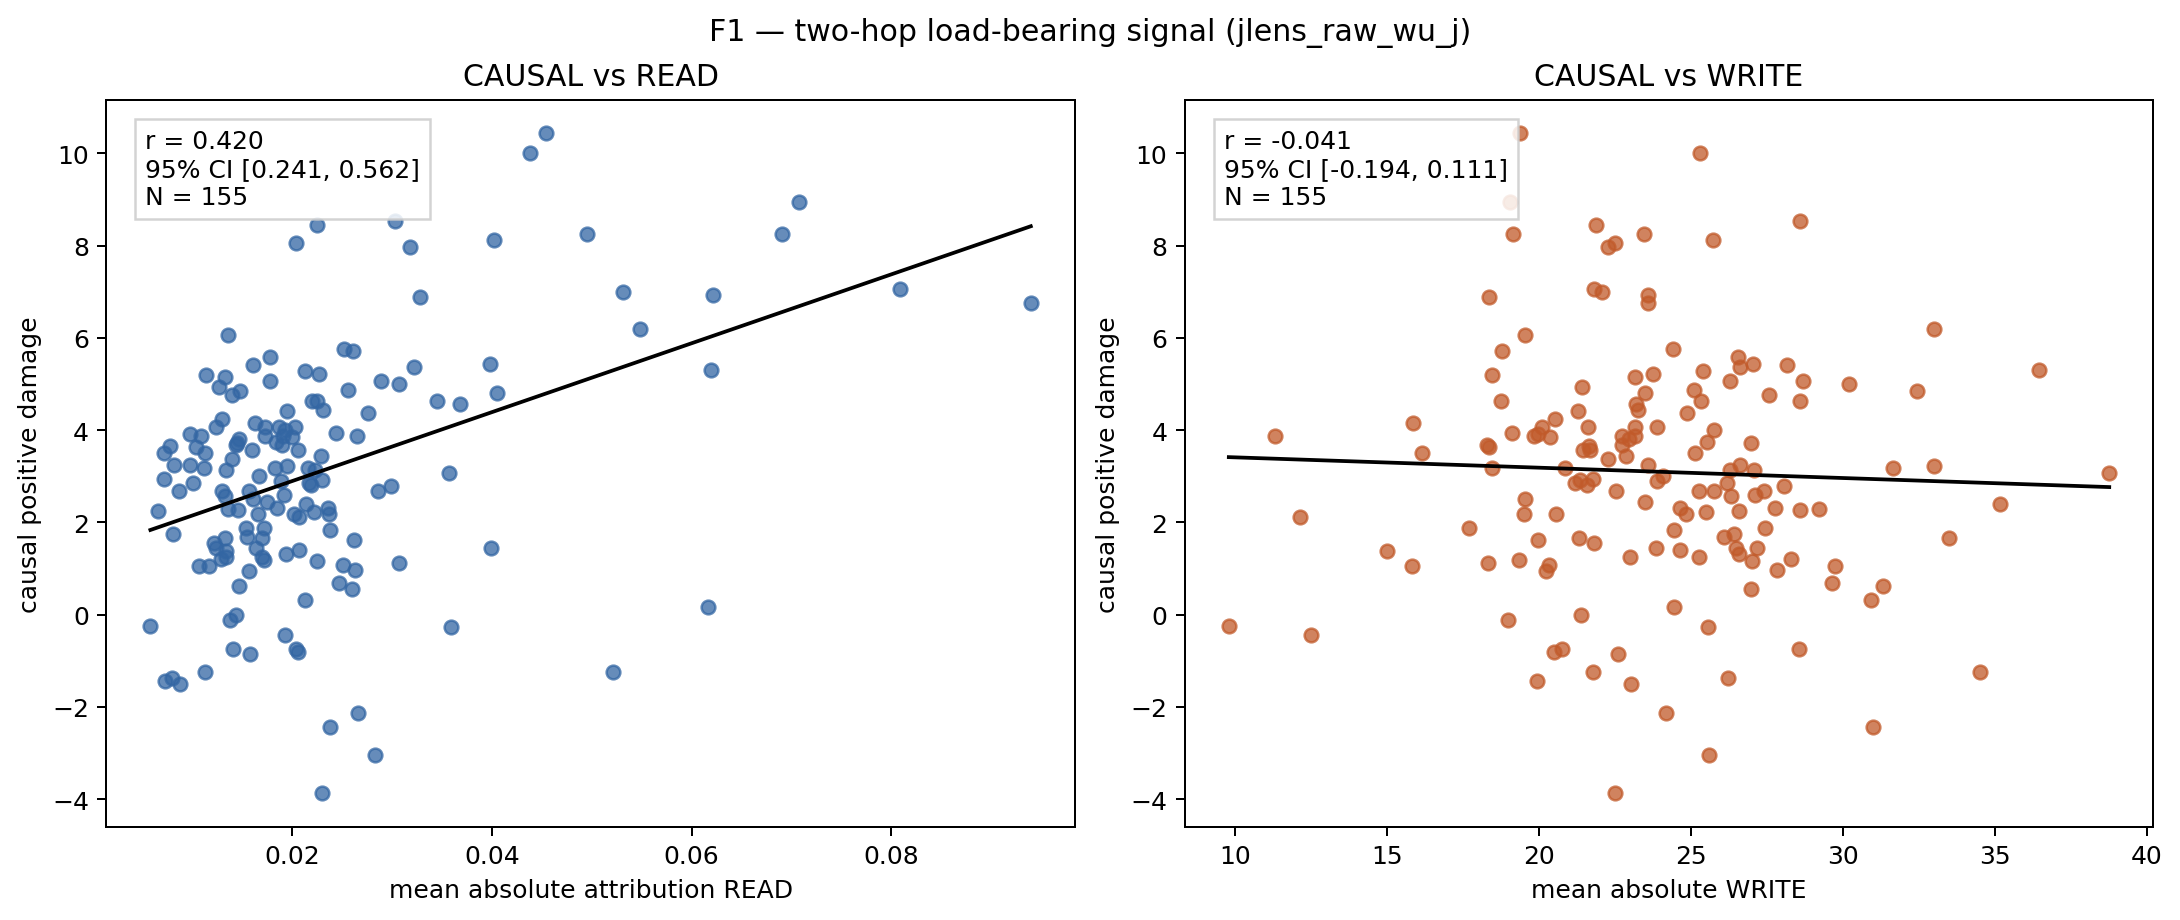

F1_14B: results/figures/f1_twohop_qwen2.5-14b.png


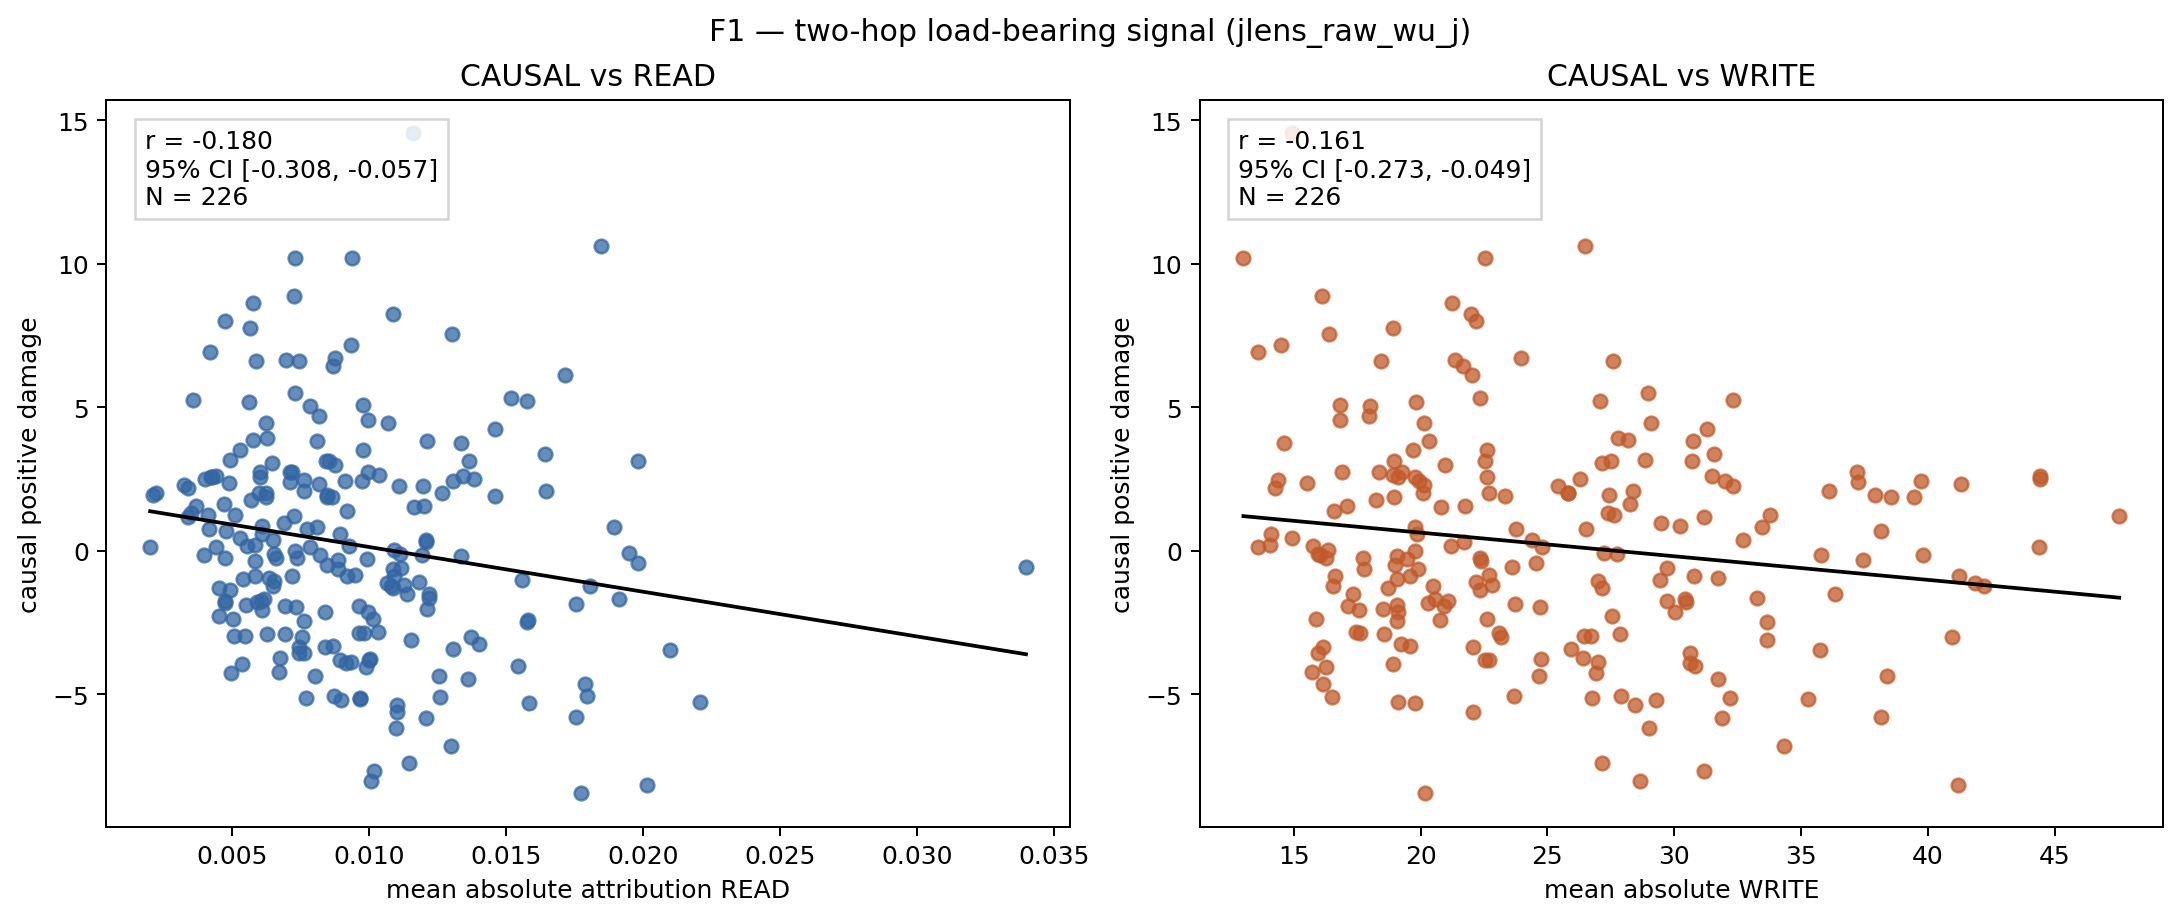

F2: results/figures/f2_twohop_qwen2.5-7b.png


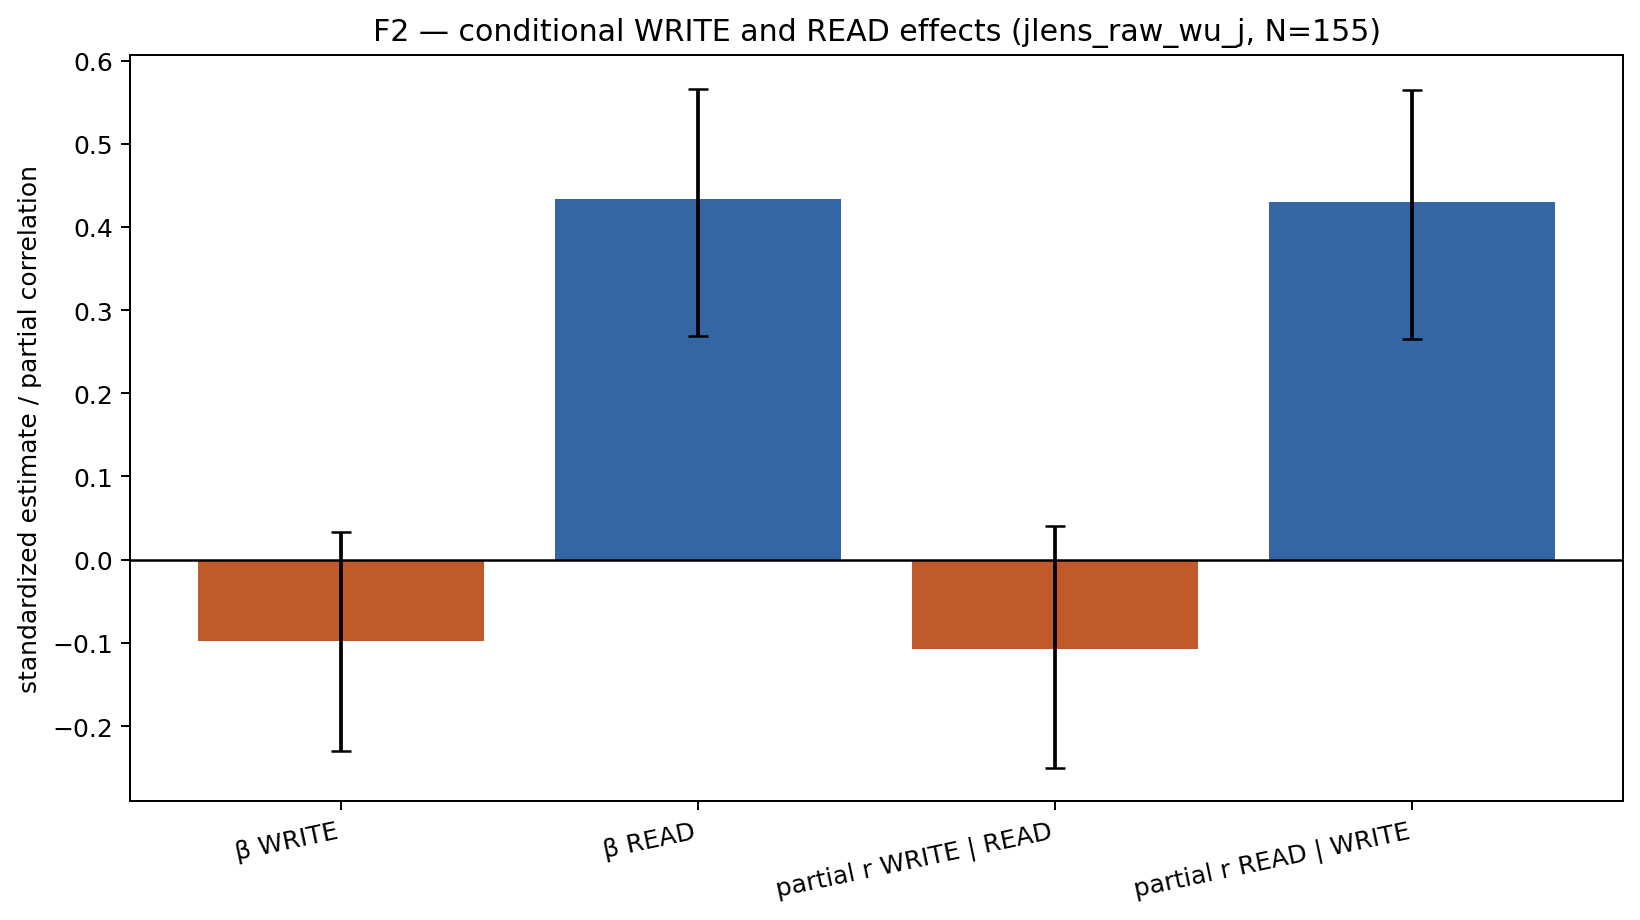

F2_14B: results/figures/f2_twohop_qwen2.5-14b.png


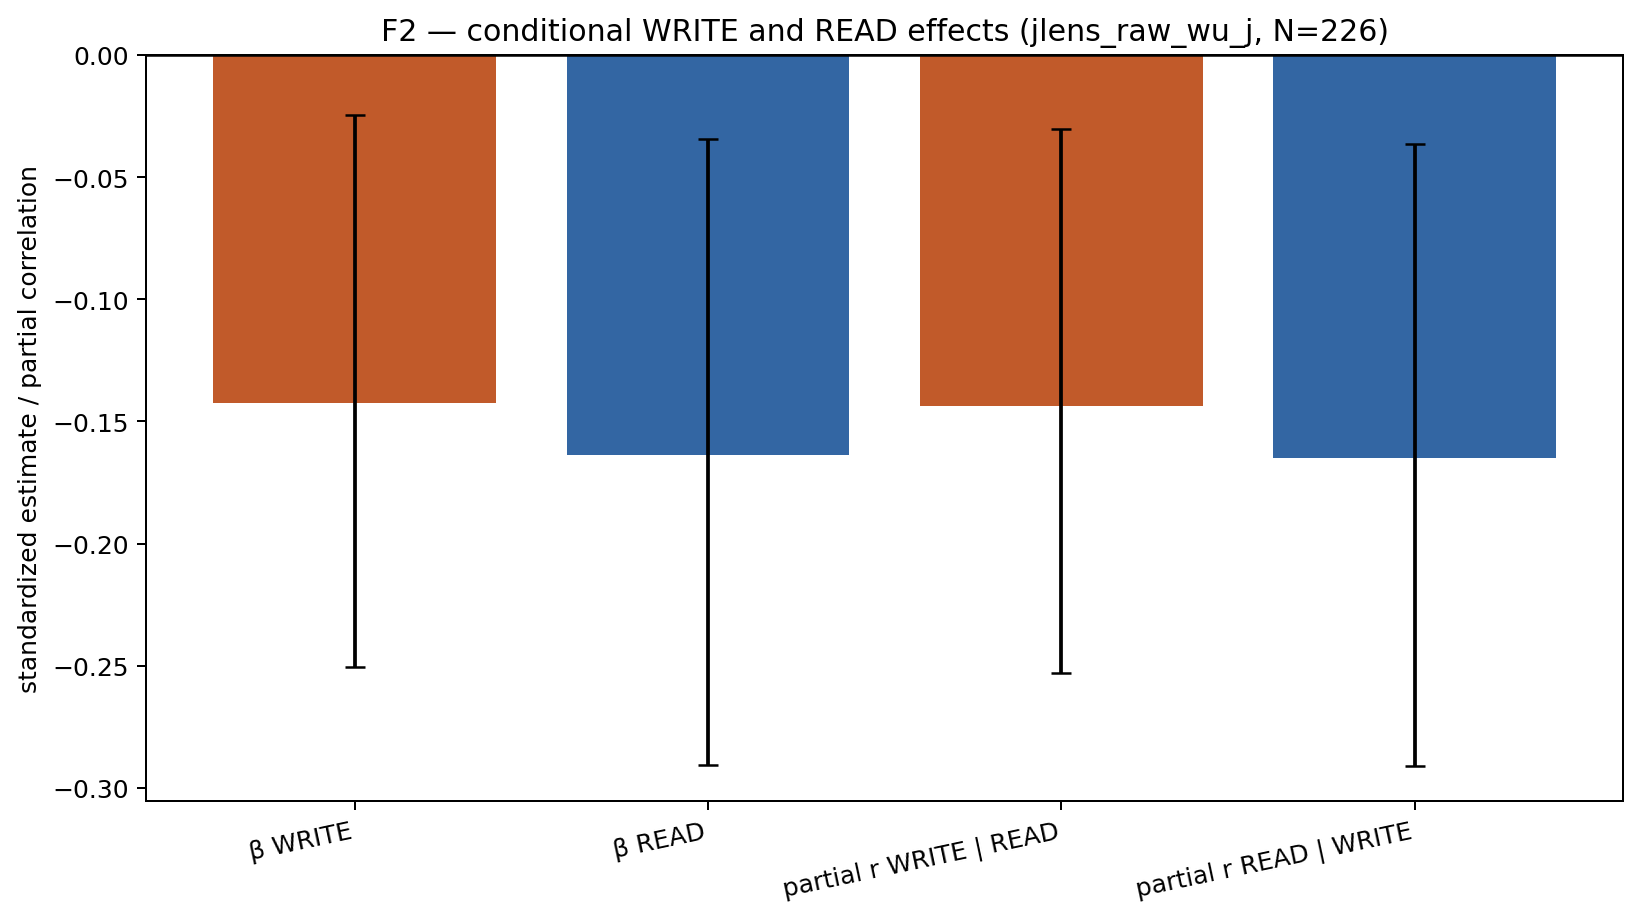

F3: results/figures/f3_internal_vs_output_suppression.png


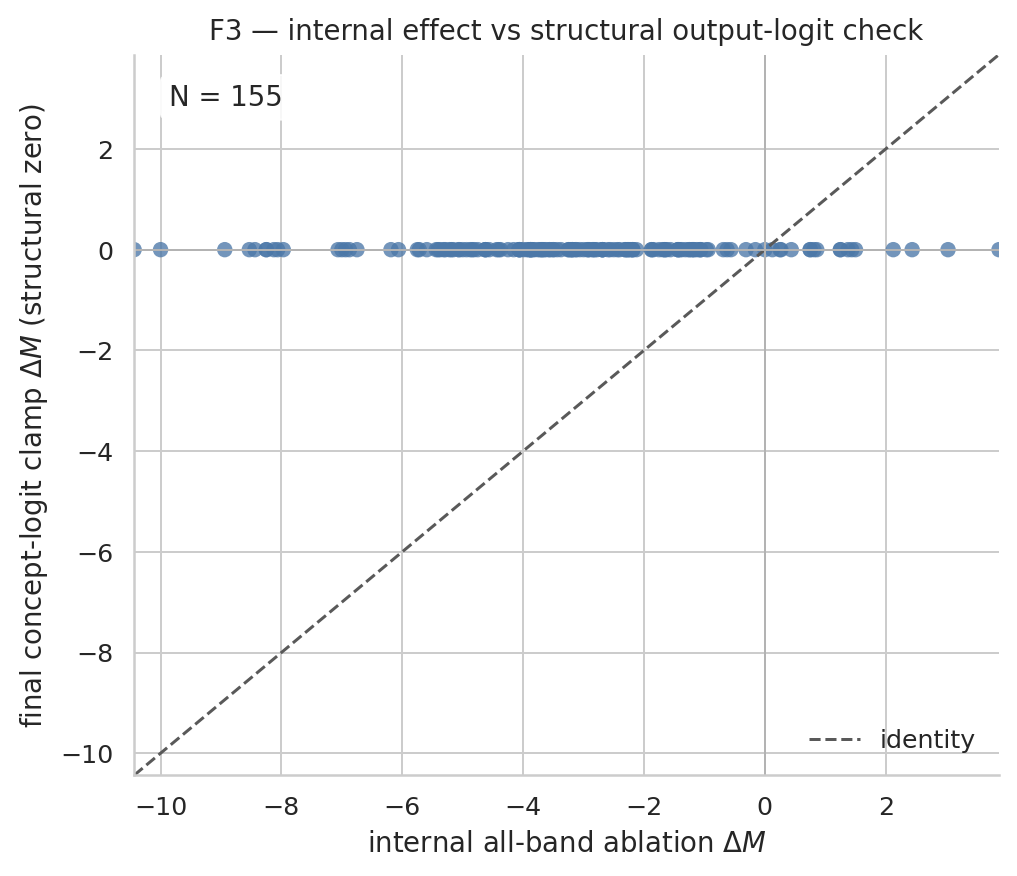

F4: results/figures/f4_read_localization_qwen2.5-7b.png


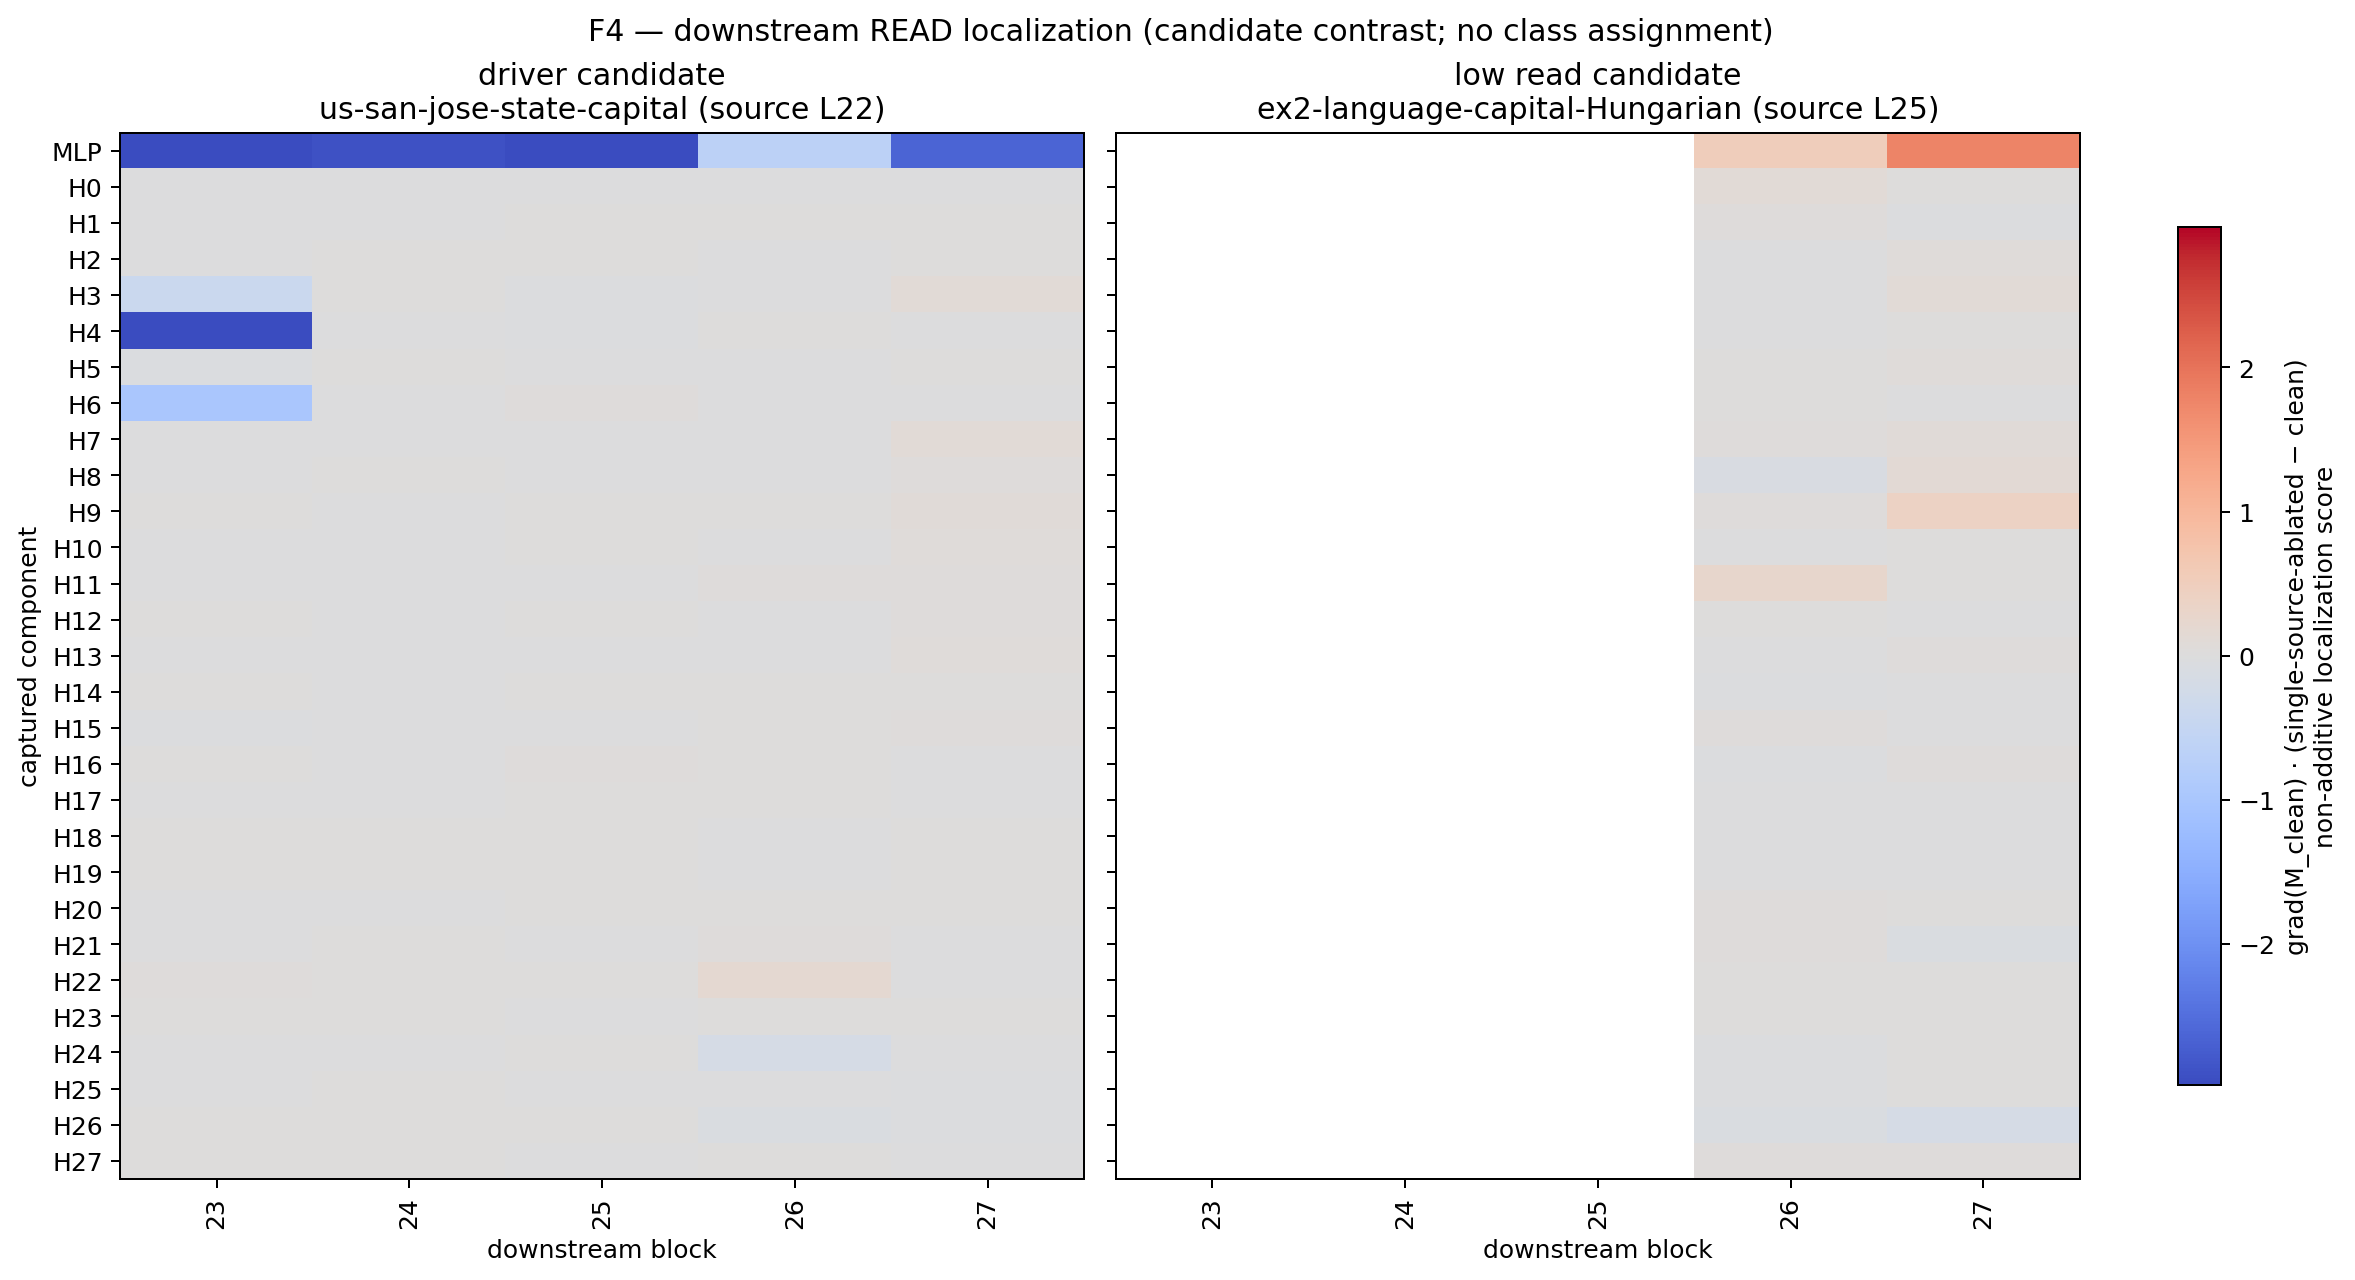

F5: results/figures/f5_attribution_vs_ablation_qwen7b.png


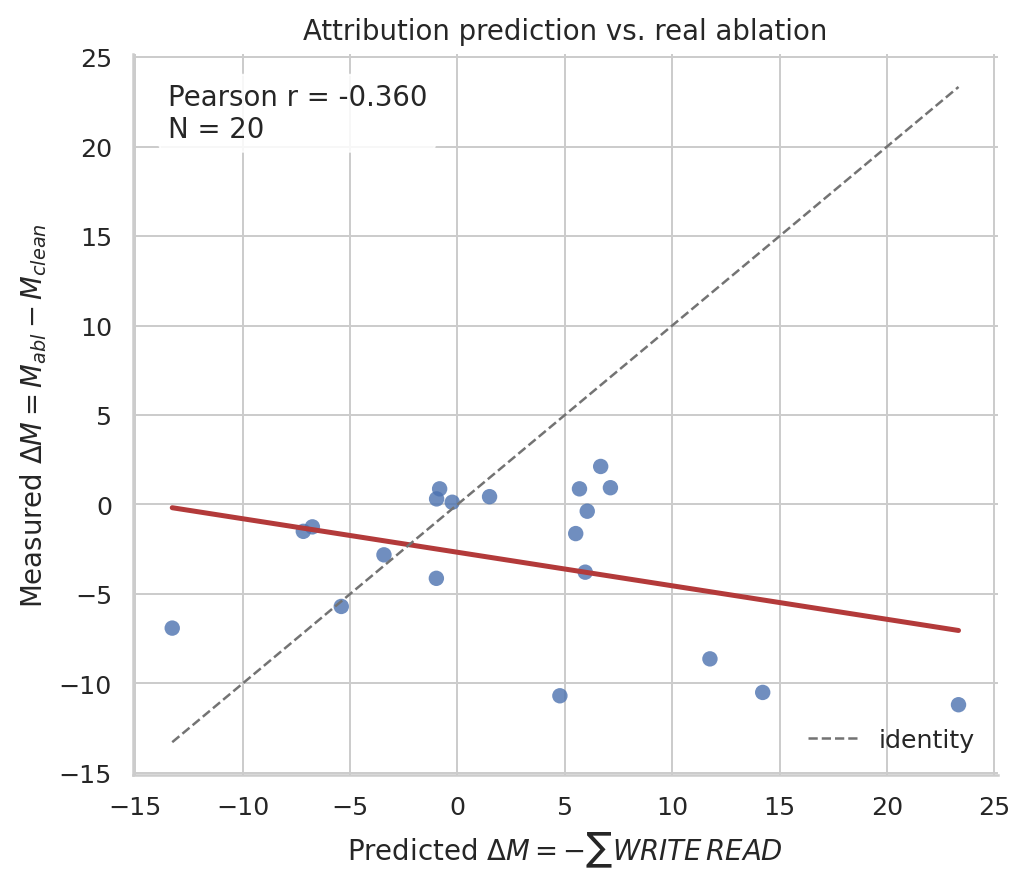

F6_14B: results/figures/f6_direction_robustness_qwen2.5-14b.png


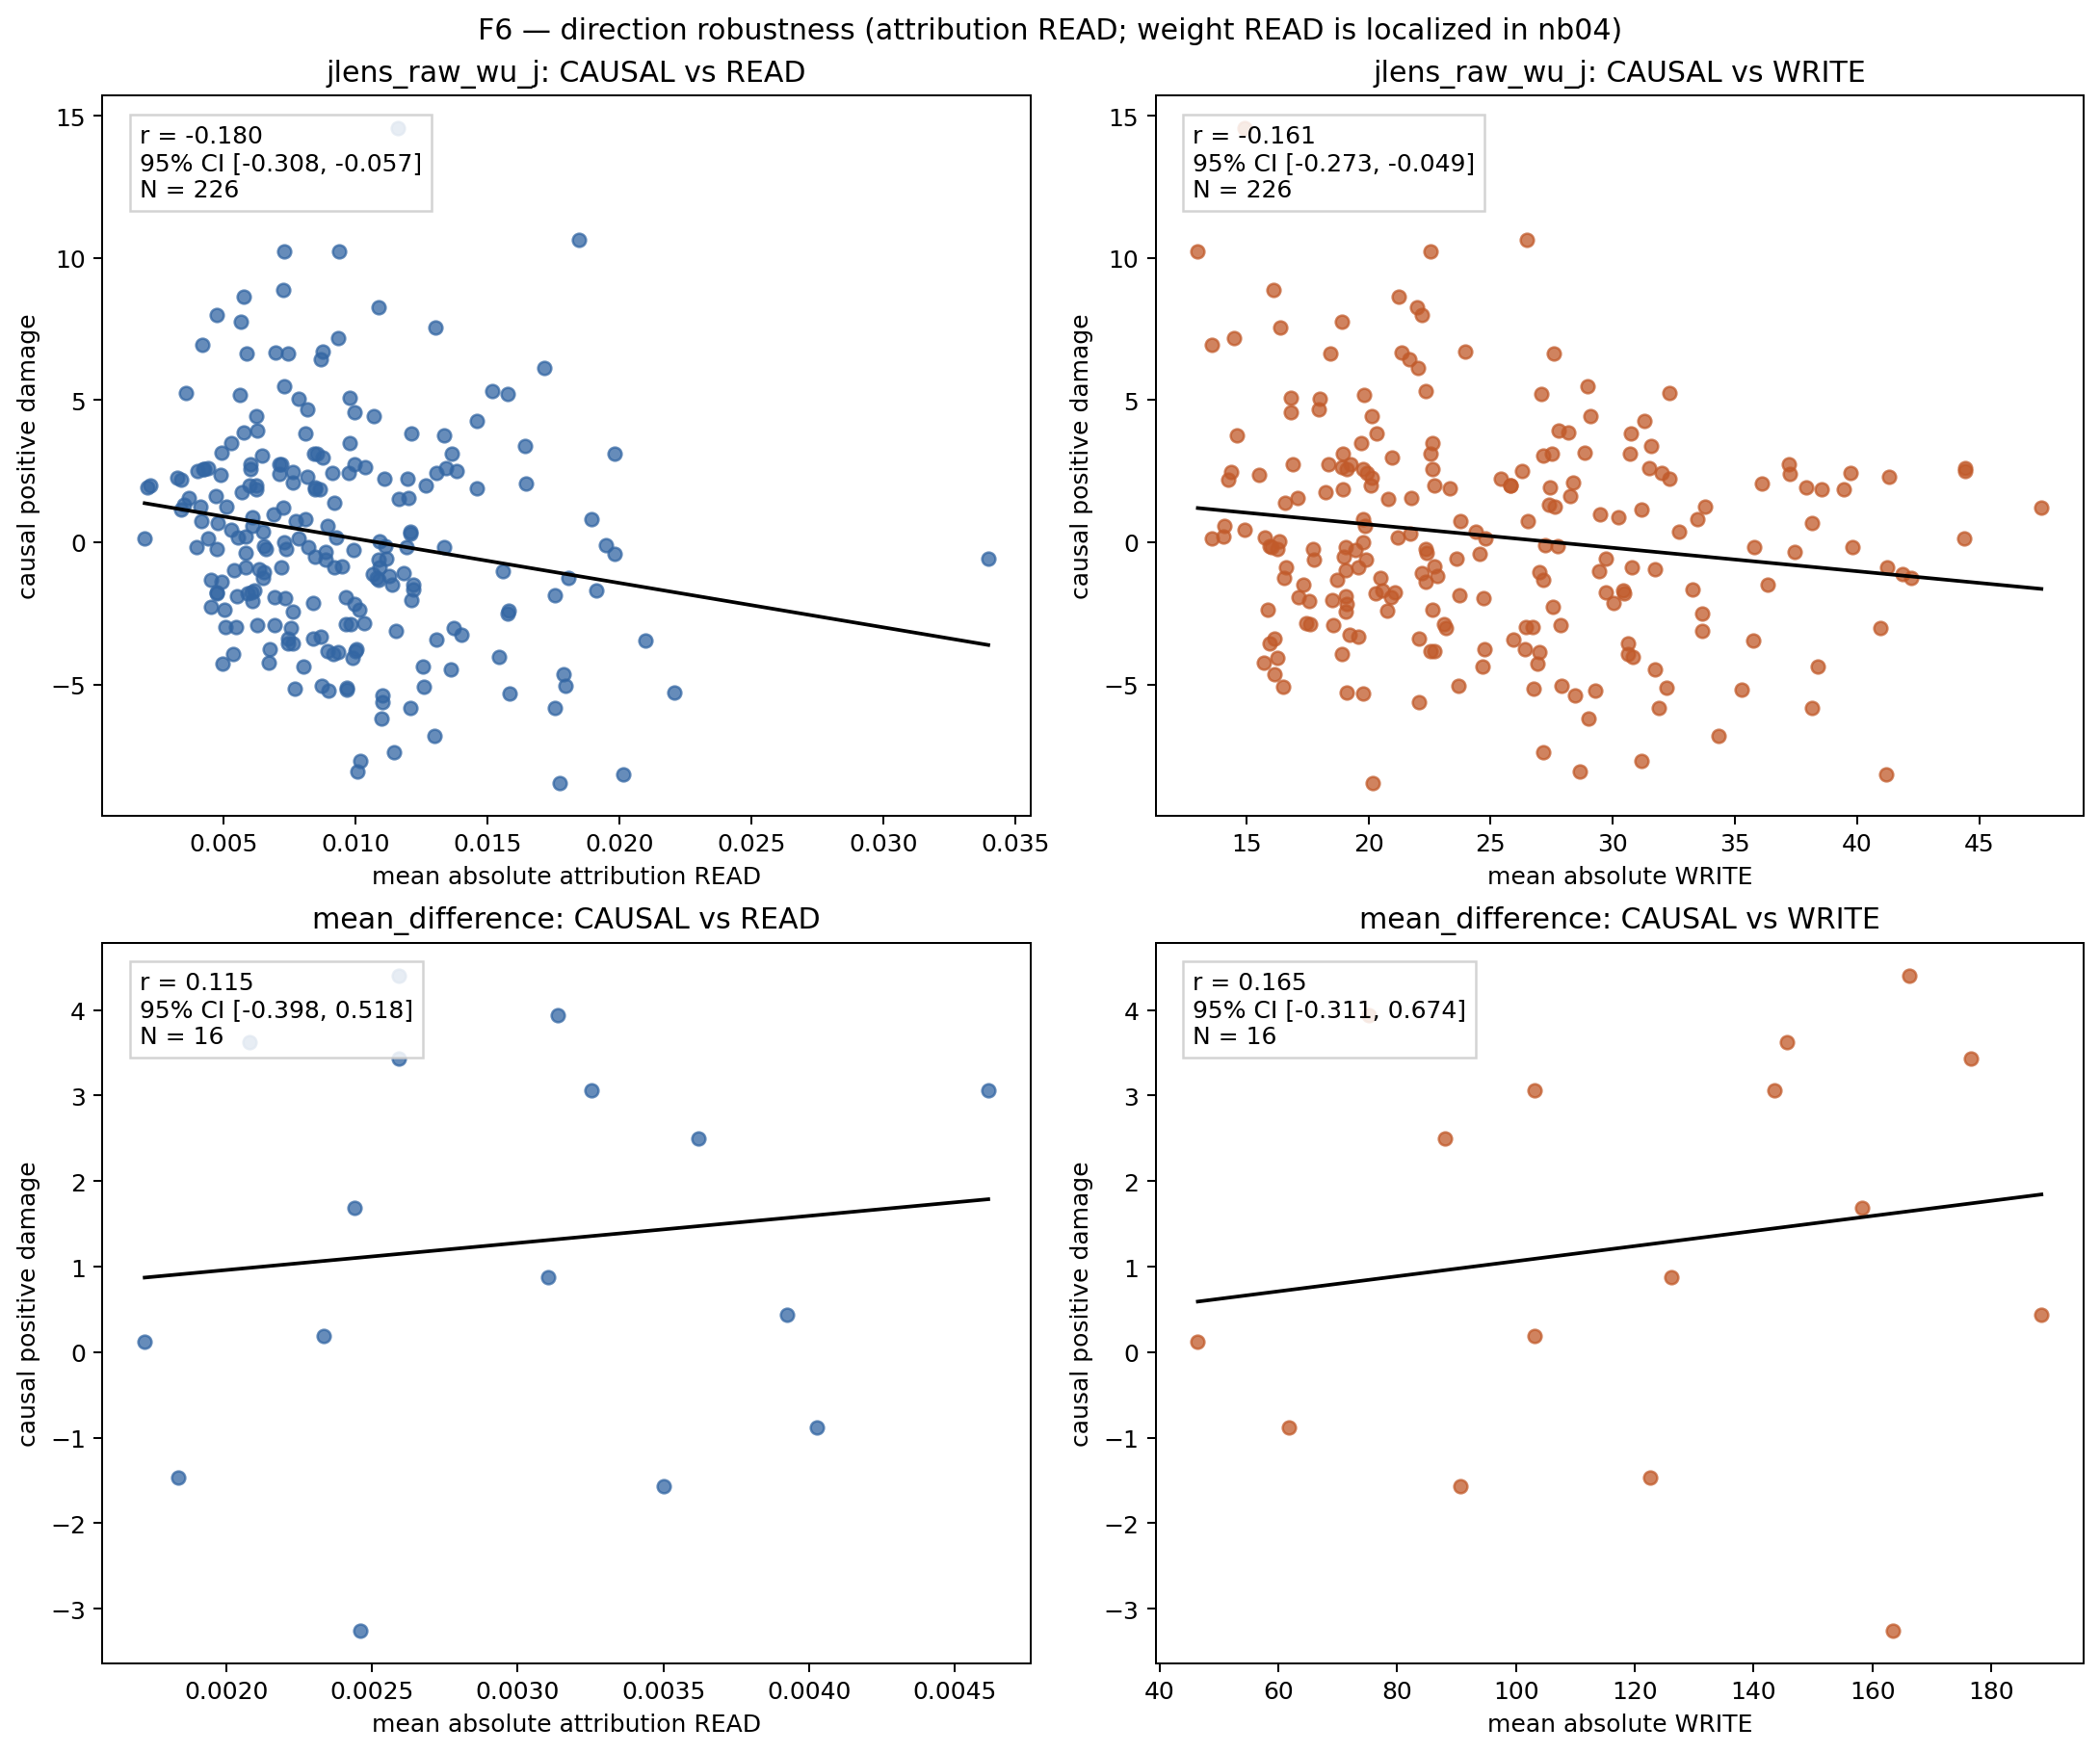

F6: results/figures/f6_direction_robustness_qwen2.5-7b.png


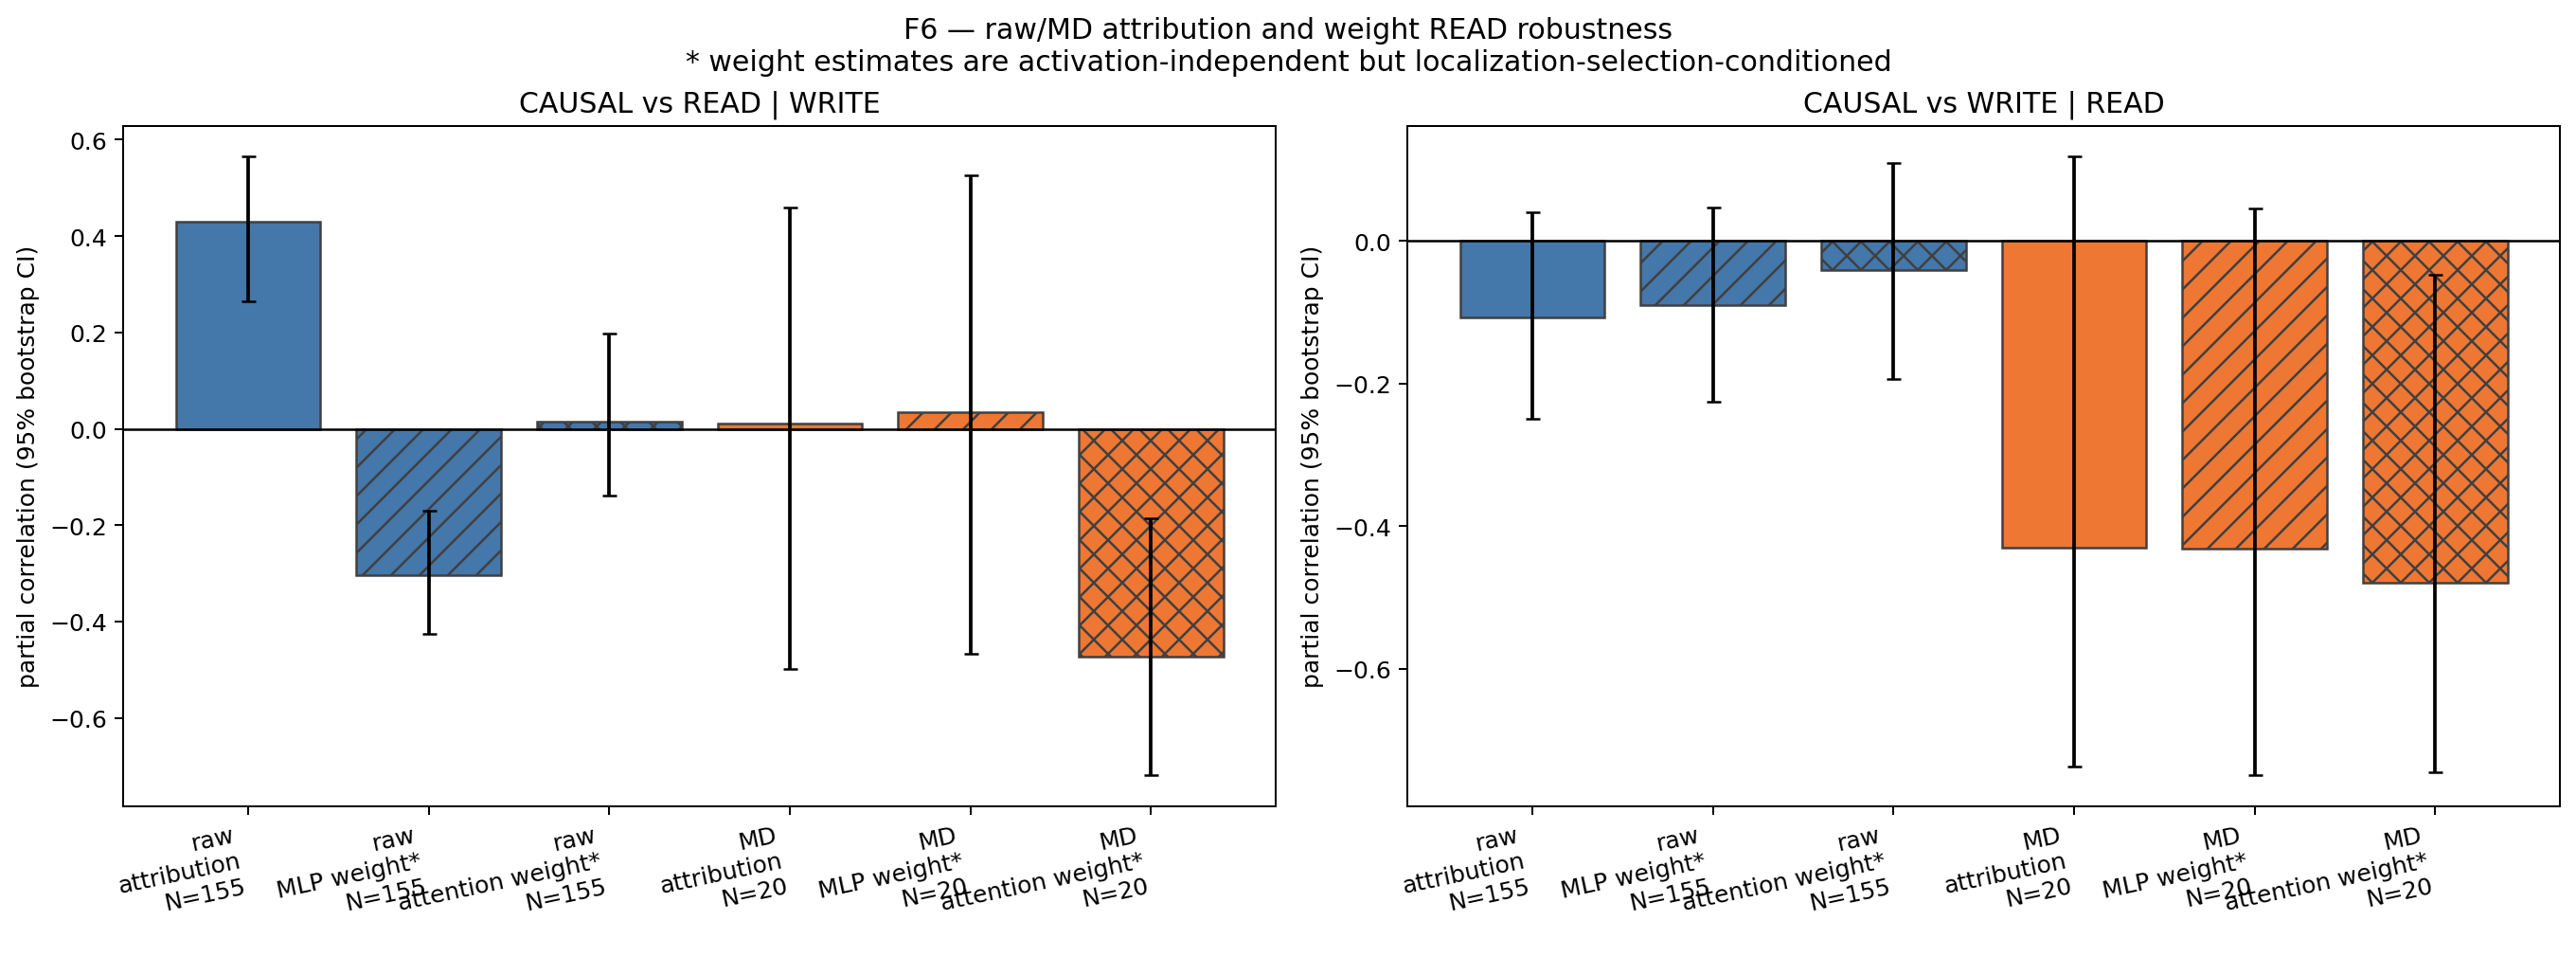

F7: results/figures/f7_scale_comparison.png


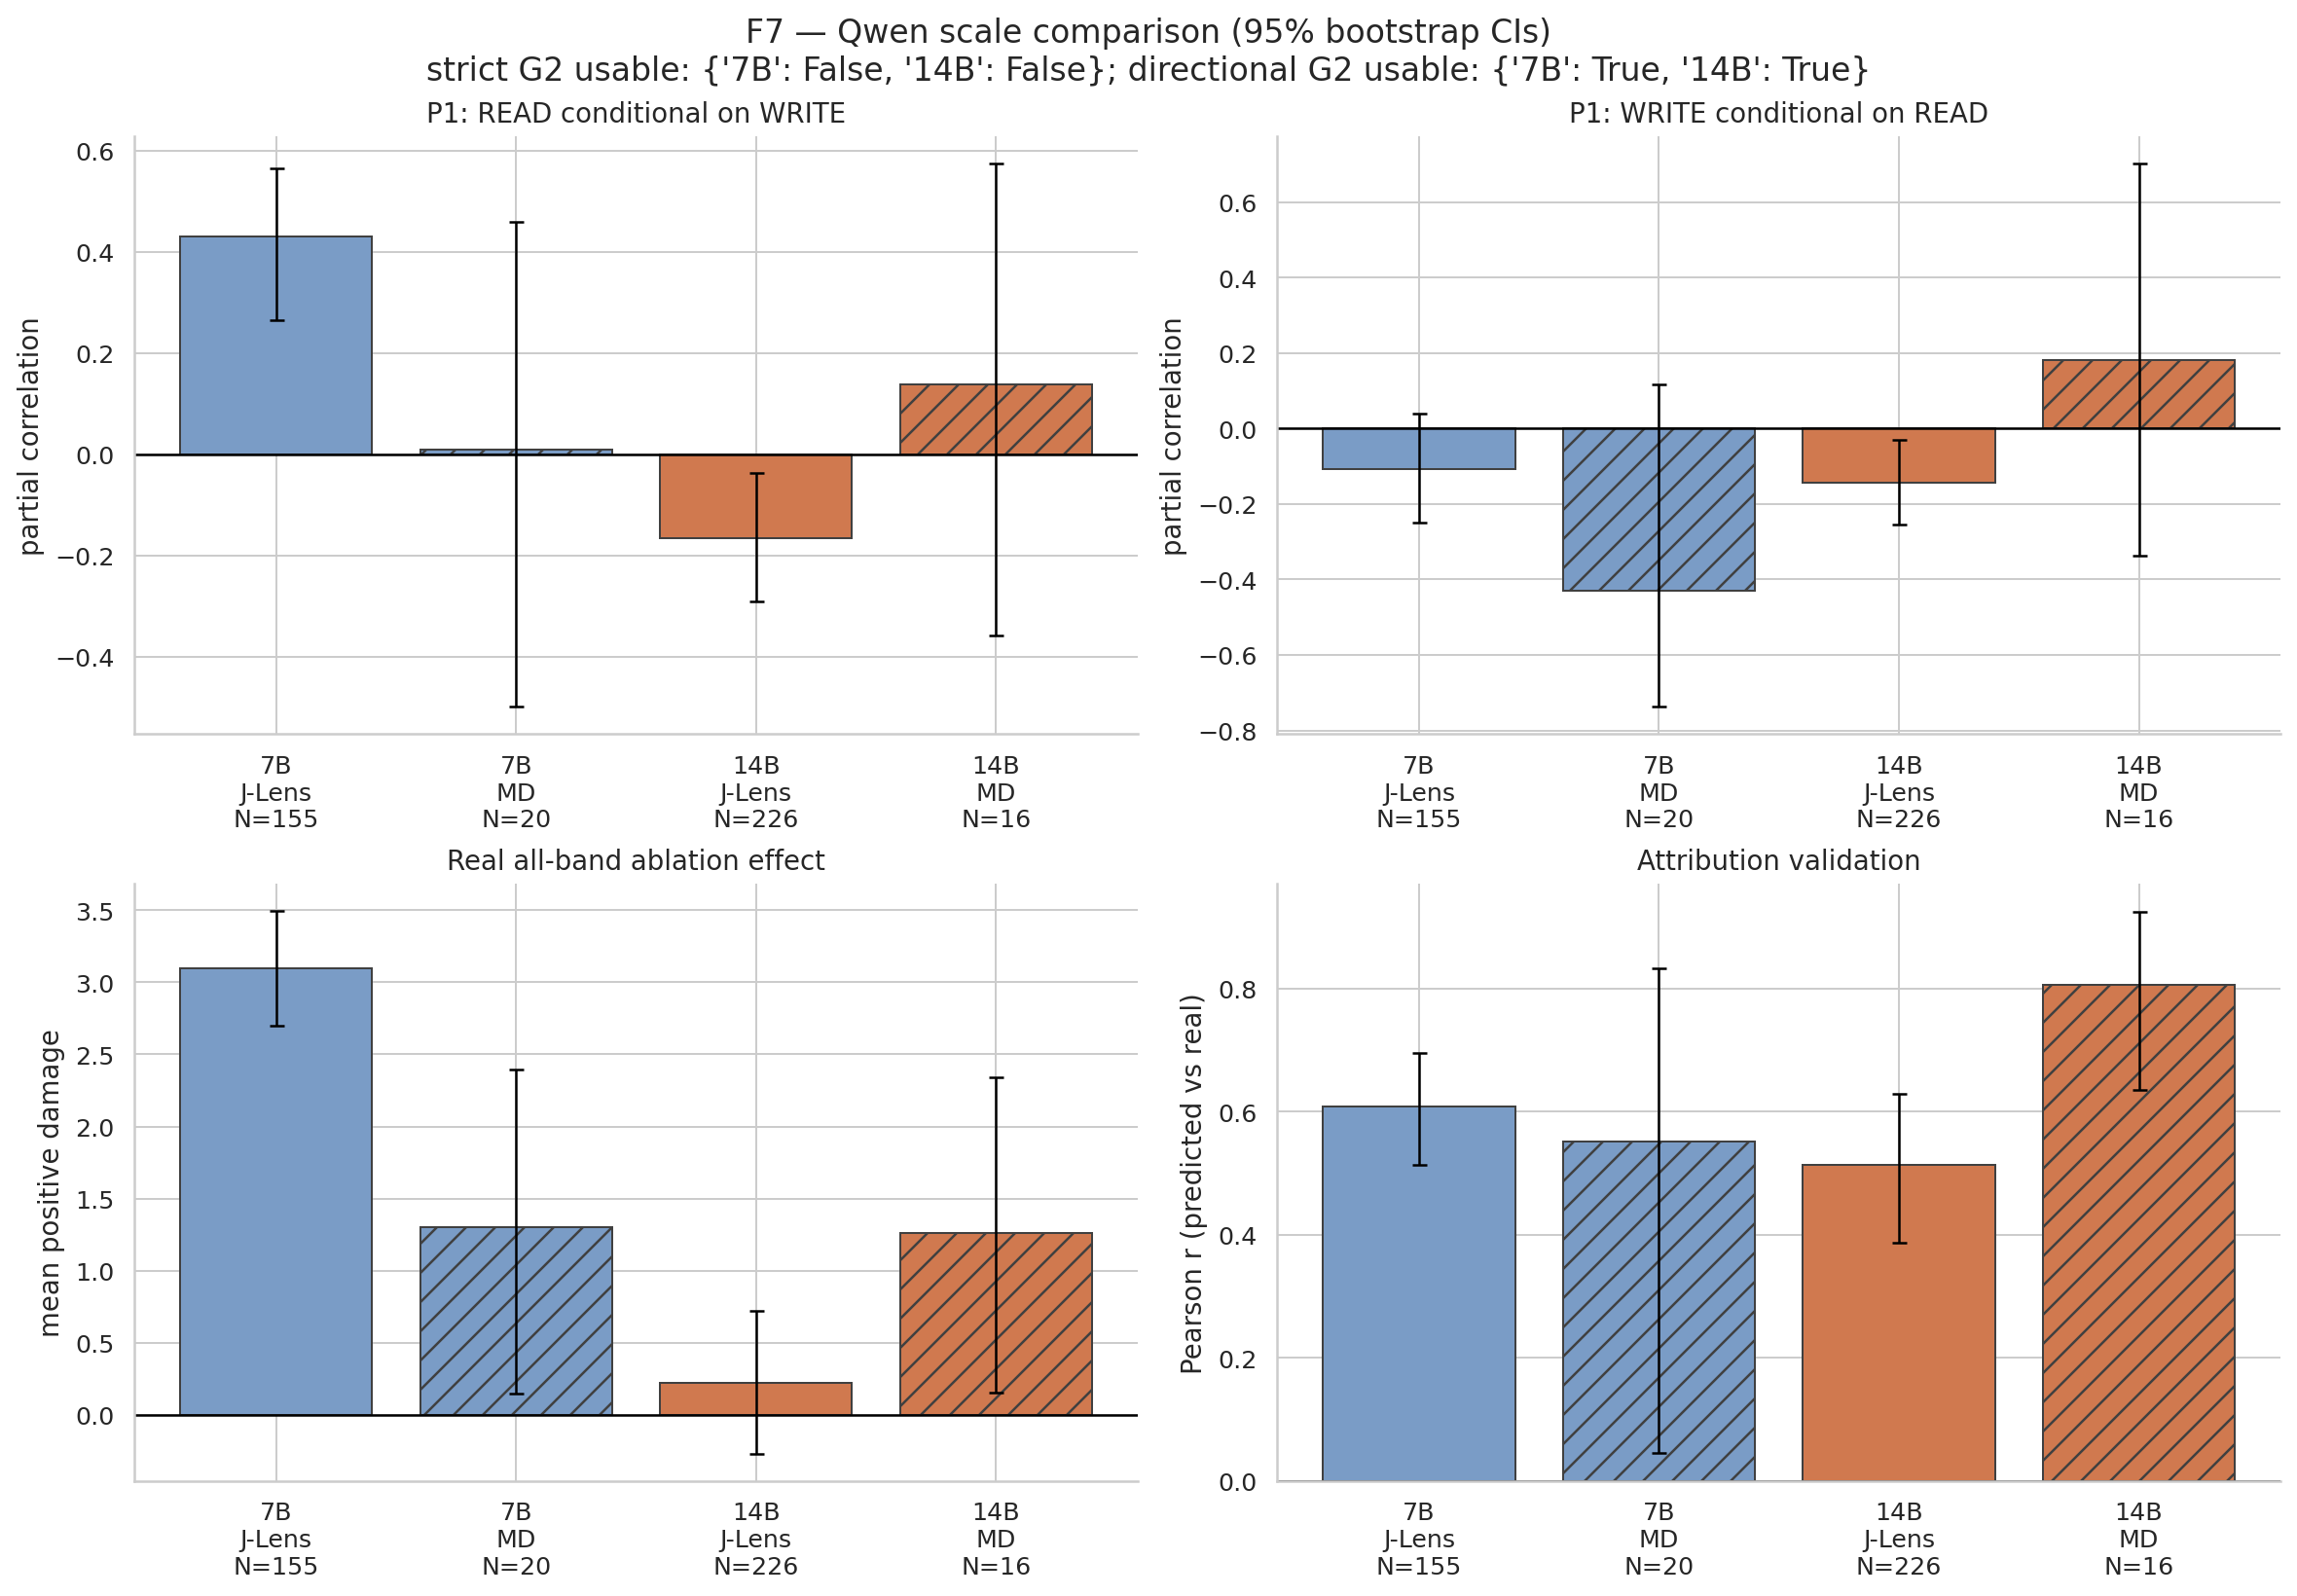

F8: results/figures/f8_ambiguity_write_read.png


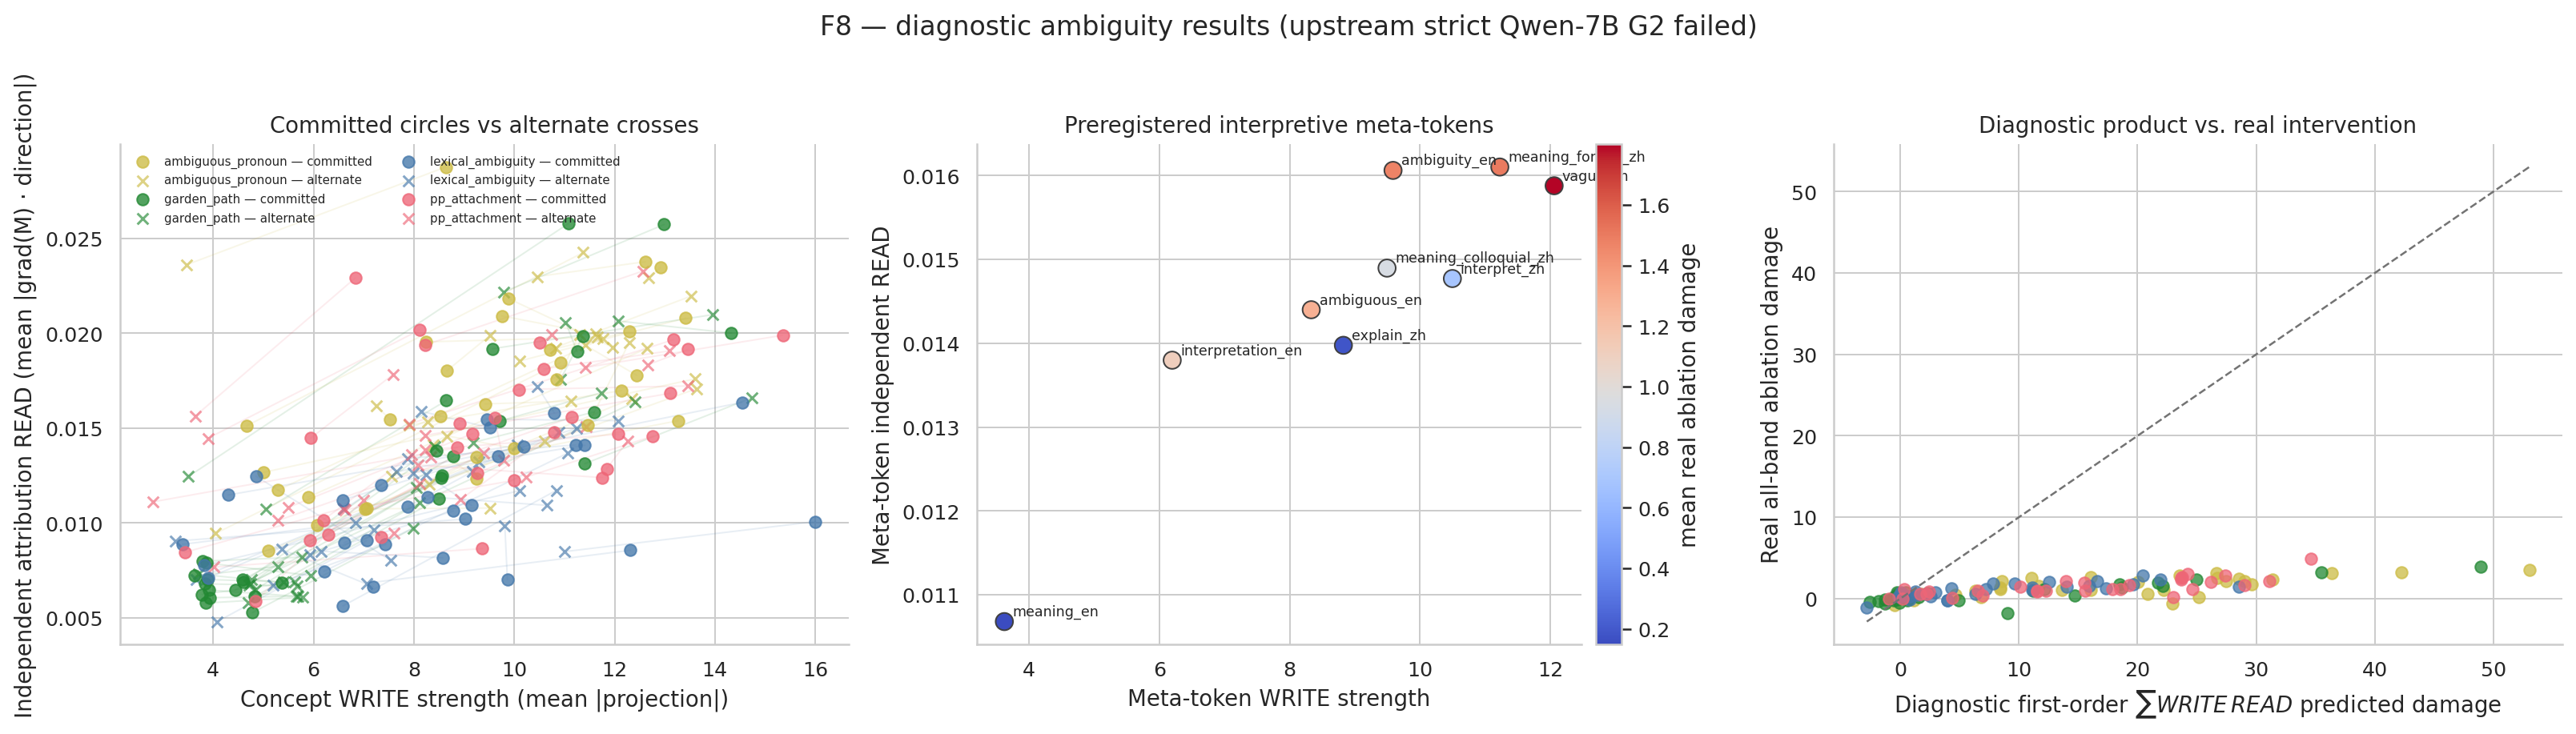

control_random: results/figures/controls_random_direction_null.png


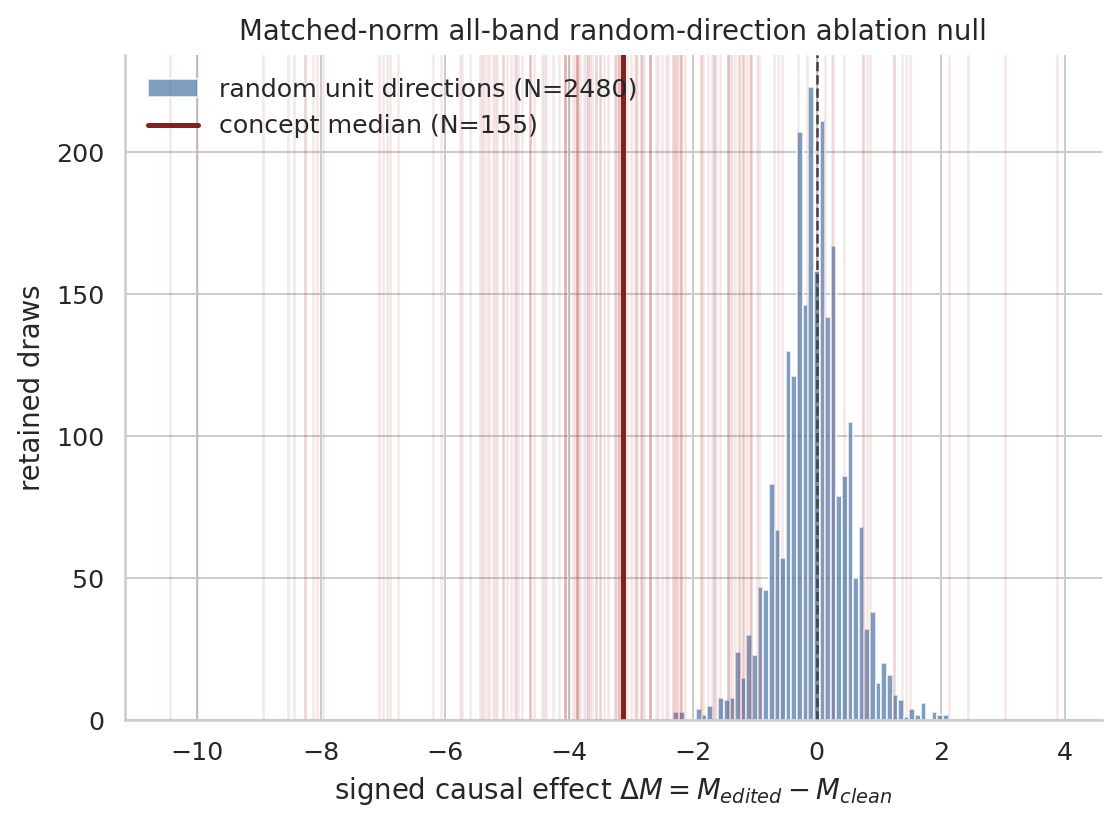

control_capability: results/figures/controls_capability.png


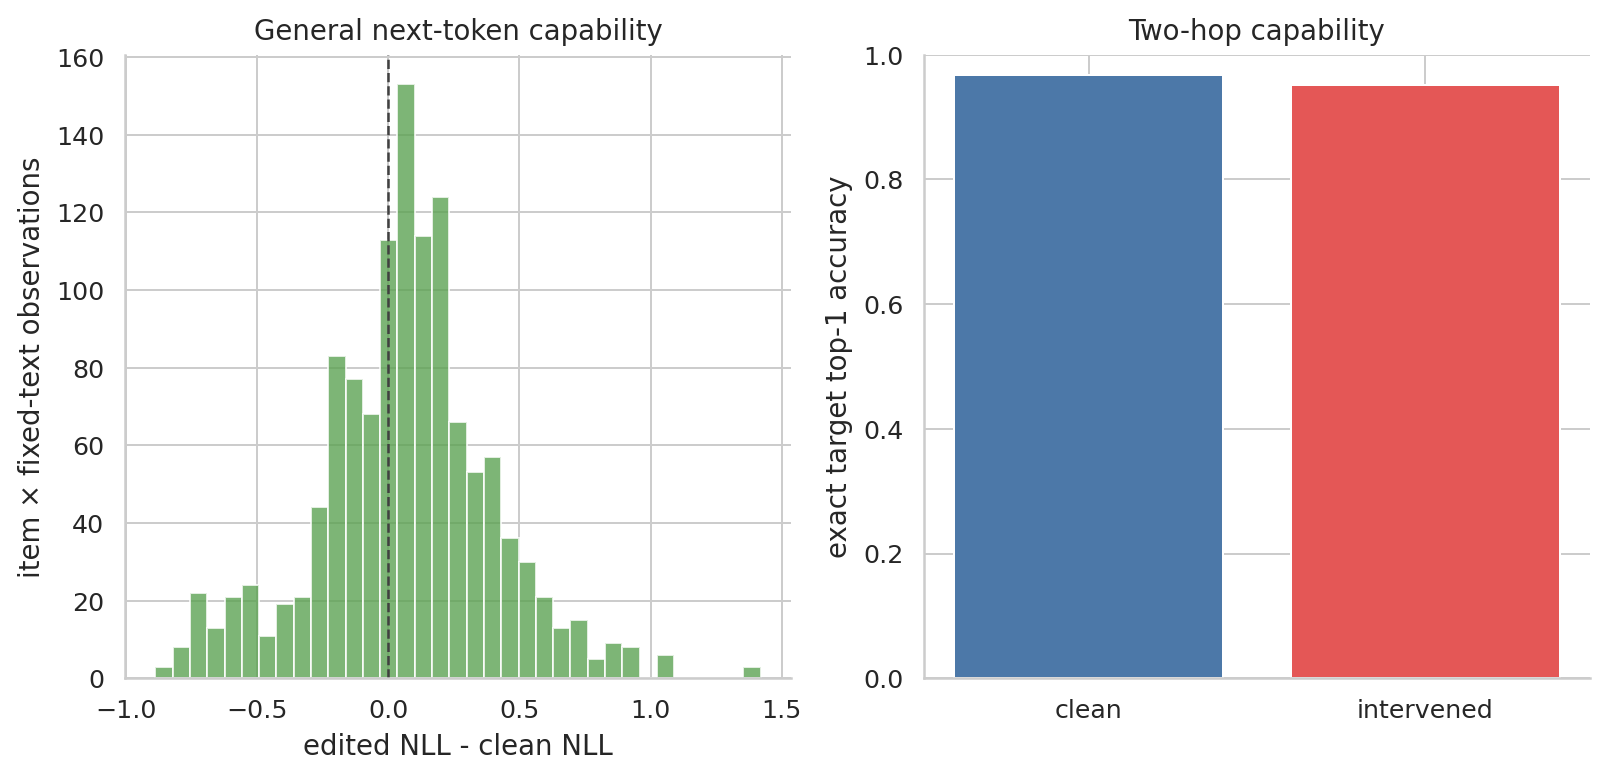

control_narration: results/figures/controls_known_narration.png


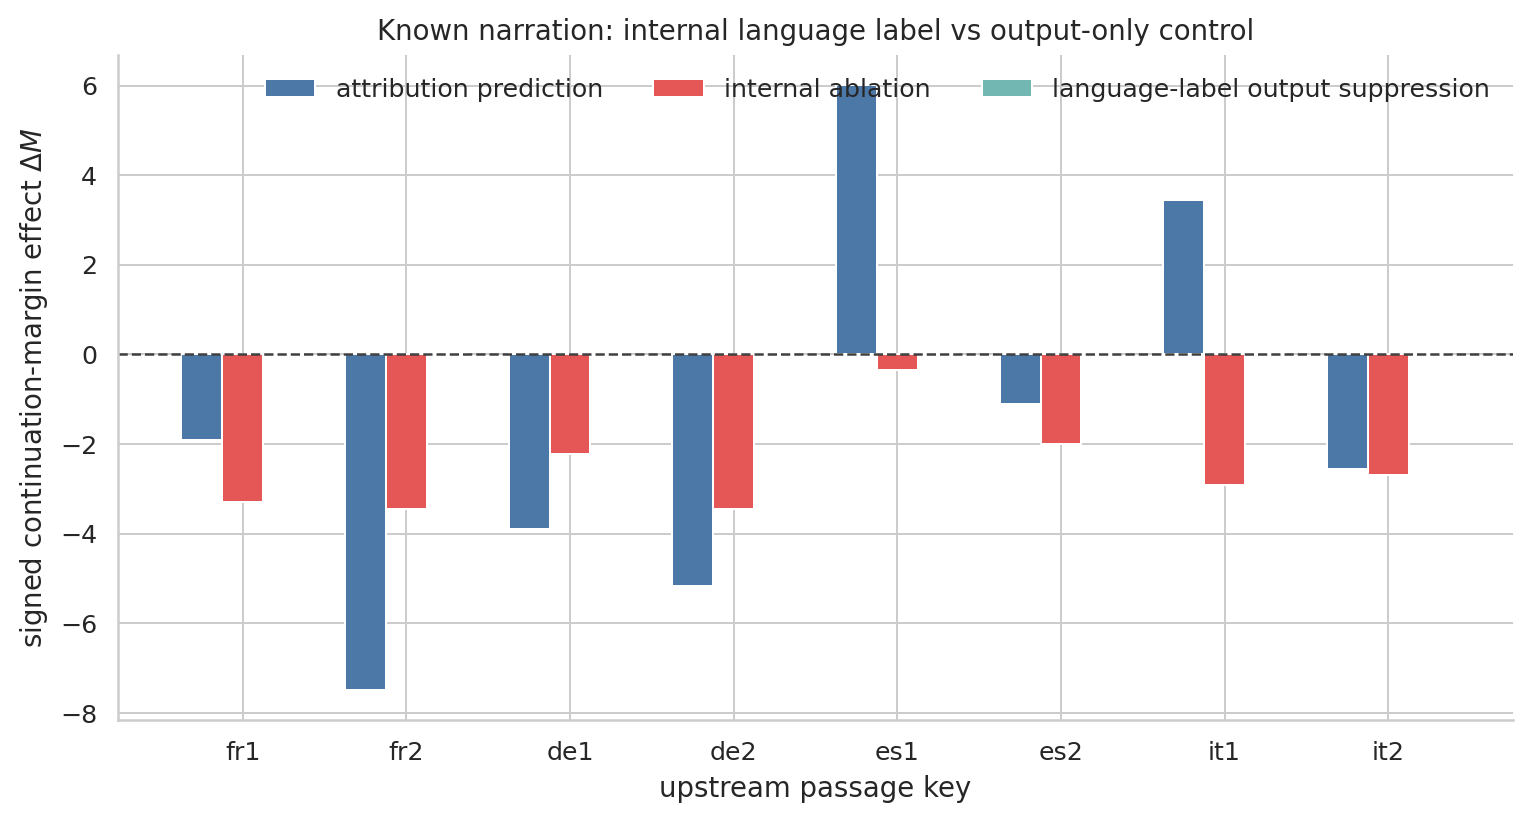

concept_alignment: results/figures/concept_direction_alignment_qwen7b.png


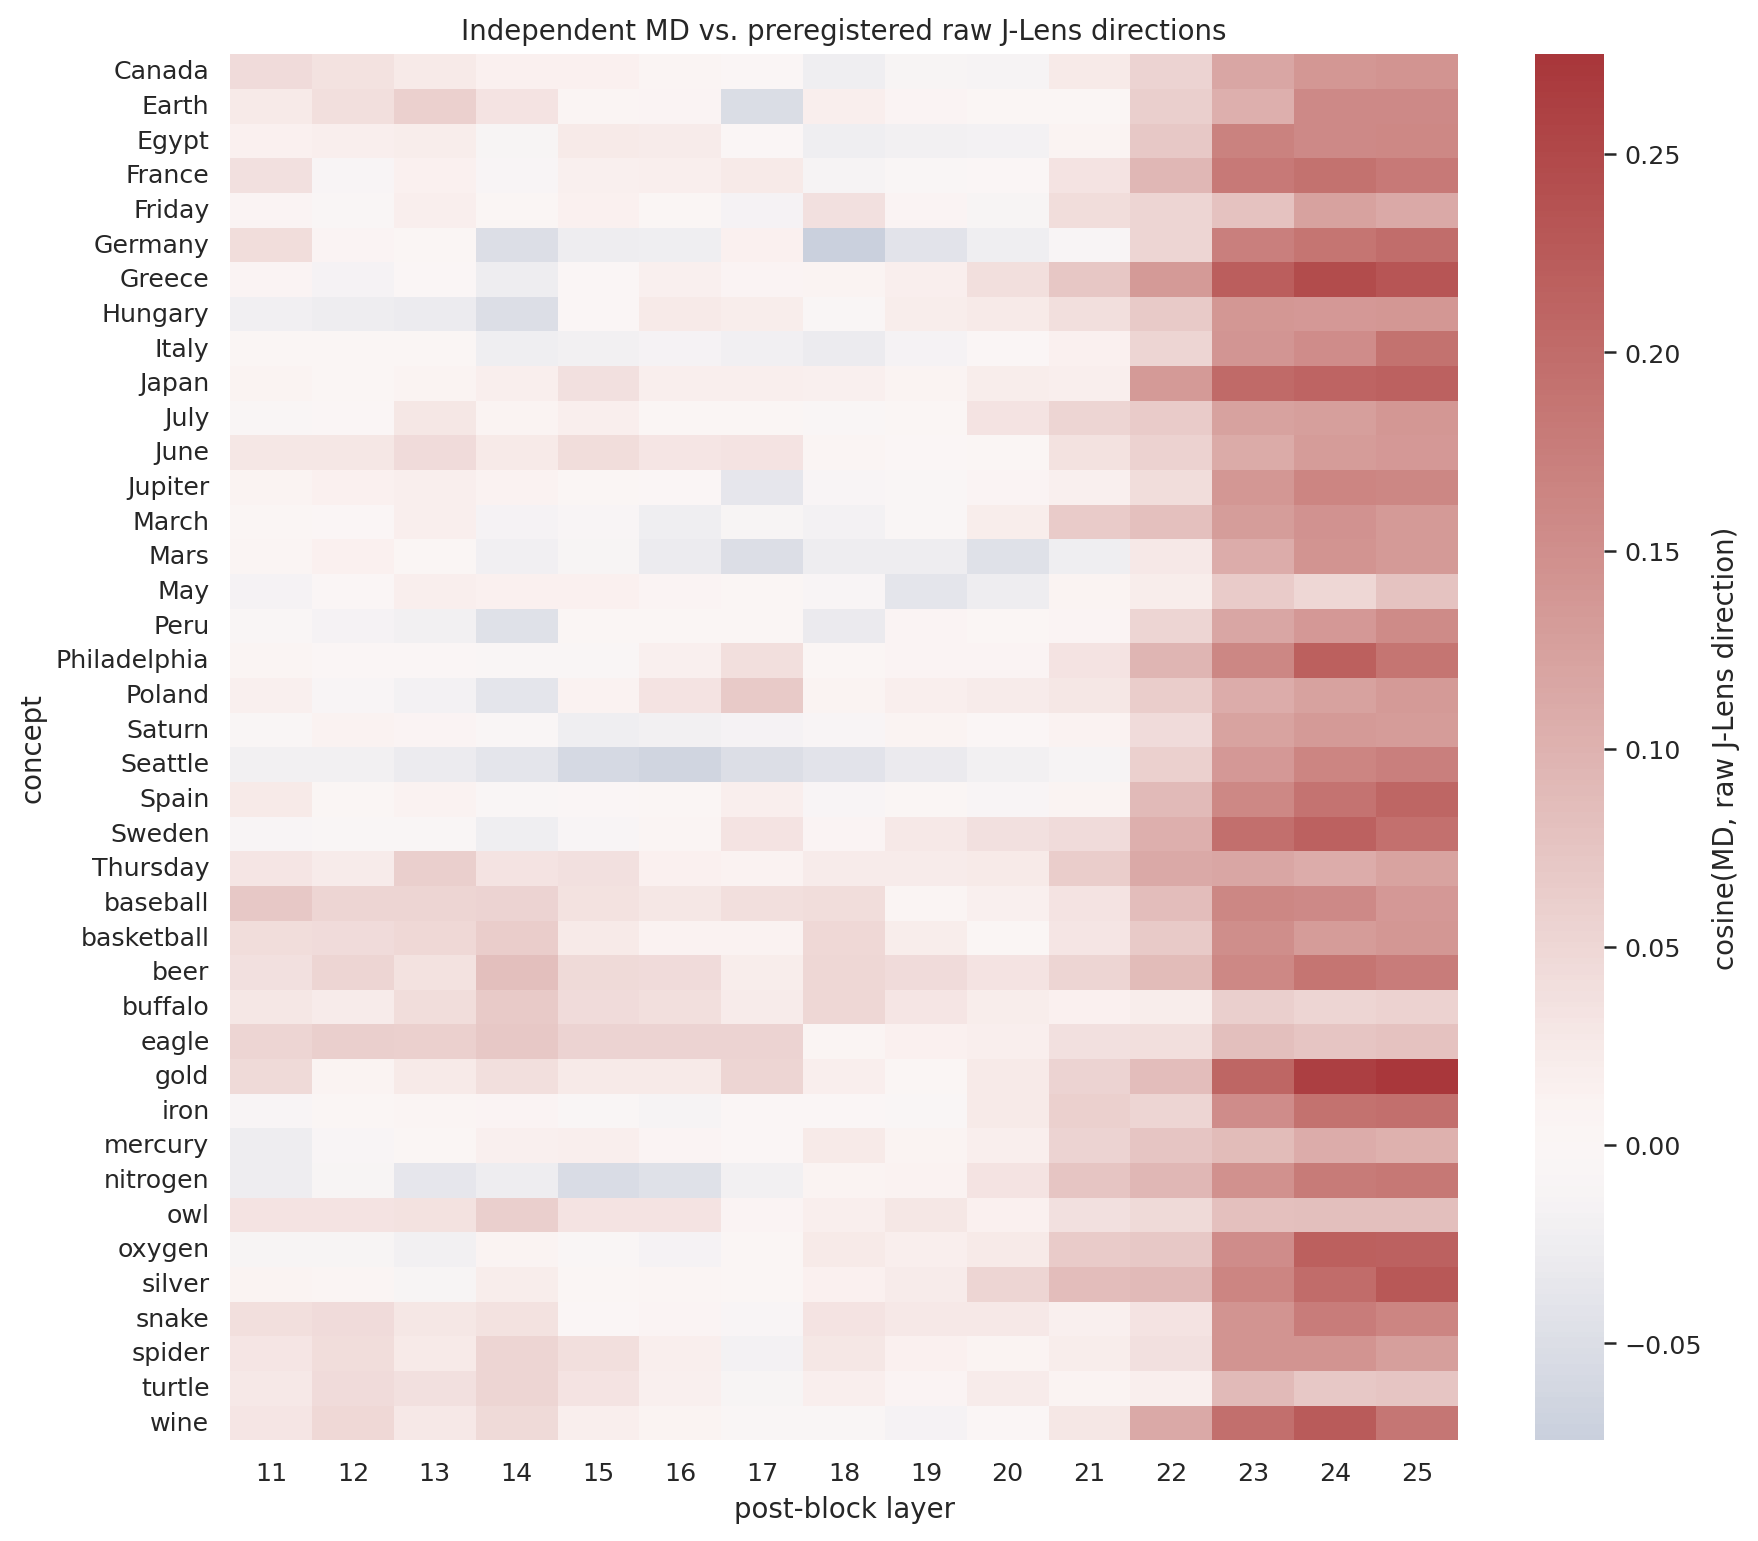

In [4]:
from IPython.display import Image, display

for figure in report["figures"]:
    if figure["exists"]:
        print(f"{figure['id']}: {figure['path']}")
        display(Image(filename=figure["absolute_path"]))

In [5]:
if report["completeness"]["status"] == "PASS":
    print("REPORT COMPLETENESS PASS")
else:
    print("REPORT COMPLETENESS FAIL")
    raise RuntimeError(report["completeness"])

print(f"Overall verdict: {summary['overall_verdict']}")
for proposition, verdict in summary["verdicts"].items():
    print(f"{proposition}: {verdict}")

REPORT COMPLETENESS PASS
Overall verdict: NOT SUPPORTED
P1: UNSUPPORTED
P2: UNESTABLISHED
P3: REFUTED
P4: NOT_RUN_OPTIONAL
